In [7]:
# ==========================================================
# Import Libraries
# ==========================================================

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error
)

# ==========================================================
# Load Feature Engineered Data
# ==========================================================

processed_dir = Path("data/processed")

sales_fe = pd.read_csv(
    processed_dir / "sales_fe.csv",
    parse_dates=["date"]
)

future_fe = pd.read_csv(
    processed_dir / "future_fe.csv",
    parse_dates=["date"]
)

predicted_customer = pd.read_csv(
    processed_dir / "predicted_customers.csv",
    parse_dates=["date"]
)

# ==========================================================
# Add Predicted Customer Feature
# ==========================================================

# Training data:
# use actual customers as the customer prediction feature
sales_fe["customer_prediction"] = sales_fe["customers"]

# Future data:
# replace unknown customers with predicted customers
future_fe = future_fe.merge(

    predicted_customer,

    on=["store_id", "date"],

    how="left"

)

# Remove original customer column (all NaN)
future_fe = future_fe.drop(columns=["customers"])

print("=" * 60)
print("CUSTOMER FEATURE CHECK")
print("=" * 60)

print("\nTraining")
print(
    sales_fe[
        [
            "customers",
            "customer_prediction"
        ]
    ].head()
)

print("\nFuture")
print(
    future_fe[
        [
            "customer_prediction"
        ]
    ].head()
)

print("\nMissing values in Future")
print(
    future_fe[
        [
            "customer_prediction"
        ]
    ].isna().sum()
)

print("=" * 60)
print("FEATURE DATA LOADED")
print("=" * 60)

print(f"Training : {sales_fe.shape}")
print(f"Future   : {future_fe.shape}")

# ==========================================================
# Prepare Modelling Dataset
# ==========================================================

target = "sales"

drop_columns = [
    "sales",
    "date"
]

feature_columns = [

    col

    for col in sales_fe.columns

    if col not in drop_columns

]

print("=" * 60)
print("FEATURE PREPARATION")
print("=" * 60)

print(f"Target Variable : {target}")
print(f"Number of Features : {len(feature_columns)}")

# ==========================================================
# Train / Validation Split
# ==========================================================

forecast_horizon = 42

cutoff_date = (

        sales_fe["date"].max()

        - pd.Timedelta(days=forecast_horizon - 1)

)

train_df = sales_fe[
    sales_fe["date"] < cutoff_date
    ].copy()

valid_df = sales_fe[
    sales_fe["date"] >= cutoff_date
    ].copy()

print("=" * 60)
print("TRAIN / VALIDATION SPLIT")
print("=" * 60)

print("Training observations :", len(train_df))
print("Validation observations:", len(valid_df))

print("\nTraining Period")
print(
    train_df["date"].min(),
    "to",
    train_df["date"].max()
)

print("\nValidation Period")
print(
    valid_df["date"].min(),
    "to",
    valid_df["date"].max()
)

# ==========================================================
# Check Missing Values
# ==========================================================

print("=" * 60)
print("MISSING VALUES BEFORE MODEL")
print("=" * 60)

print("\nTraining Data")
print(
    train_df.isna()
    .sum()
    .sort_values(ascending=False)
)

print("\nValidation Data")
print(
    valid_df.isna()
    .sum()
    .sort_values(ascending=False)
)

print("\nFuture Data")
print(
    future_fe.isna()
    .sum()
    .sort_values(ascending=False)
)

# ==========================================================
# Remove Missing Values
# ==========================================================

rows_before = len(train_df)

train_df = train_df.dropna().reset_index(drop=True)

rows_after = len(train_df)

print("=" * 60)
print("REMOVE MISSING VALUES")
print("=" * 60)

print(f"Rows before : {rows_before:,}")
print(f"Rows after  : {rows_after:,}")
print(f"Rows removed: {rows_before - rows_after:,}")

# ==========================================================
# Prepare Model Inputs
# ==========================================================

drop_columns = [

    "sales",

    "date",

    "store_id",

    "customers"

]

X_train = train_df.drop(columns=drop_columns)
y_train = train_df[target]

X_valid = valid_df.drop(columns=drop_columns)
y_valid = valid_df[target]

print("=" * 60)
print("MODEL MATRICES")
print("=" * 60)

print("X_train :", X_train.shape)
print("y_train :", y_train.shape)

print("\nX_valid :", X_valid.shape)
print("y_valid :", y_valid.shape)

print("=" * 60)
print("FEATURE DATA TYPES")
print("=" * 60)

print(X_train.dtypes.value_counts())

object_cols = X_train.select_dtypes(include="object").columns.tolist()

print("\nObject columns:")
print(object_cols)

print("\nFeature contains customer_prediction:")
print("customer_prediction" in X_train.columns)

CUSTOMER FEATURE CHECK

Training
   customers  customer_prediction
0        785                  785
1        654                  654
2        626                  626
3        615                  615
4        592                  592

Future
   customer_prediction
0           437.370690
1           667.137207
2           673.250164
3           752.277034
4           676.591182

Missing values in Future
customer_prediction    0
dtype: int64
FEATURE DATA LOADED
Training : (624624, 62)
Future   : (40560, 61)
FEATURE PREPARATION
Target Variable : sales
Number of Features : 60
TRAIN / VALIDATION SPLIT
Training observations : 596232
Validation observations: 28392

Training Period
2013-01-07 00:00:00 to 2015-06-07 00:00:00

Validation Period
2015-06-08 00:00:00 to 2015-07-19 00:00:00
MISSING VALUES BEFORE MODEL

Training Data
rolling_mean_28        18928
rolling_max_28         18928
rolling_median_28      18928
rolling_std_28         18928
rolling_min_28         18928
                     

TRAIN GLOBAL RANDOM FOREST

Number of Features : 58

Customer Feature Included : True
Training completed.
PREDICTION COMPLETED
Prediction length : 28392
RANDOM FOREST PERFORMANCE BY STORE TYPE
                    MAE         RMSE       MAPE  Stores
store_type                                             
A           2098.929850  3031.943604  31.232479     364
B           1816.331913  2668.555216  33.052715      11
C           2039.816193  2978.164983  30.934261      75
D           2241.075548  3266.999243  31.227339     206


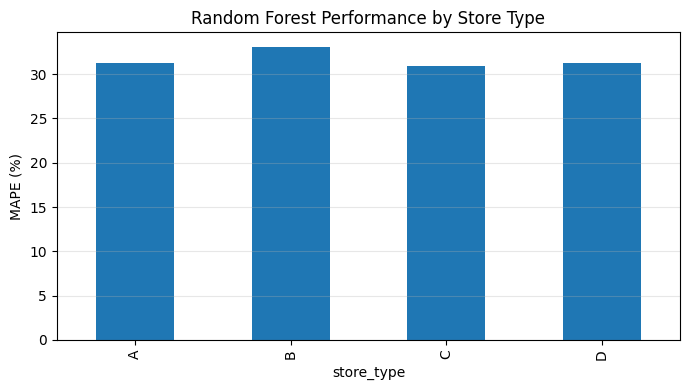

RANDOM FOREST PERFORMANCE
MAE  : 2603.30
RMSE : 3515.60
MAPE : 31.22%


In [8]:
# ==========================================================
# Train Global Random Forest
# ==========================================================

from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=300,
    max_features="sqrt",
    min_samples_leaf=10,
    random_state=42,
    n_jobs=-1
)

print("=" * 60)
print("TRAIN GLOBAL RANDOM FOREST")
print("=" * 60)

print("\nNumber of Features :", X_train.shape[1])

print("\nCustomer Feature Included :",
      "customer_prediction" in X_train.columns)

rf.fit(
    X_train,
    y_train
)

print("Training completed.")

# ==========================================================
# Validation Prediction
# ==========================================================

y_pred = rf.predict(X_valid)

print("=" * 60)
print("PREDICTION COMPLETED")
print("=" * 60)

print("Prediction length :", len(y_pred))

# ==========================================================
# Save Validation Results
# ==========================================================

valid_result = valid_df.copy()

valid_result["prediction"] = y_pred

valid_result["abs_error"] = np.abs(

    valid_result["sales"] -

    valid_result["prediction"]

)

valid_result["ape"] = (

                              np.abs(

                                  valid_result["sales"]

                                  -

                                  valid_result["prediction"]

                              )

                              /

                              valid_result["sales"]

                      ) * 100

valid_result = valid_result[

    valid_result["sales"] != 0

    ]

# ==========================================================
# Store Type Performance
# ==========================================================

valid_result["store_type"] = np.select(

    [

        valid_result["store_type_a"] == 1,

        valid_result["store_type_b"] == 1,

        valid_result["store_type_c"] == 1,

        valid_result["store_type_d"] == 1,

    ],

    [

        "A",

        "B",

        "C",

        "D"

    ]

)

rf_storetype = (

    valid_result

    .groupby("store_type")

    .agg(

        MAE=("abs_error", "mean"),

        RMSE=("abs_error", lambda x: np.sqrt(np.mean(x ** 2))),

        MAPE=("ape", "mean"),

        Stores=("store_id", "nunique")

    )

)

print("=" * 60)
print("RANDOM FOREST PERFORMANCE BY STORE TYPE")
print("=" * 60)

print(rf_storetype)

plt.figure(figsize=(7, 4))

rf_storetype["MAPE"].plot(
    kind="bar"
)

plt.ylabel("MAPE (%)")

plt.title(
    "Random Forest Performance by Store Type"
)

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

plt.show()

# ==========================================================
# Overall Model Evaluation
# ==========================================================

mae = mean_absolute_error(
    y_valid,
    y_pred
)

rmse = np.sqrt(

    mean_squared_error(

        y_valid,

        y_pred

    )

)

mask = y_valid != 0

mape = (

           np.abs(

               (

                       y_valid[mask]

                       -

                       y_pred[mask]

               )

               /

               y_valid[mask]

           ).mean()

       ) * 100

print("=" * 60)
print("RANDOM FOREST PERFORMANCE")
print("=" * 60)

print(f"MAE  : {mae:.2f}")

print(f"RMSE : {rmse:.2f}")

print(f"MAPE : {mape:.2f}%")

ERROR SUMMARY
          abs_error           ape
count  23680.000000  23680.000000
mean    2132.011019     31.222453
std     2244.620081     29.741644
min        0.139271      0.001944
25%      721.799077     11.922179
50%     1546.842317     25.142501
75%     2718.813773     42.070327
max    32765.807590    814.812475


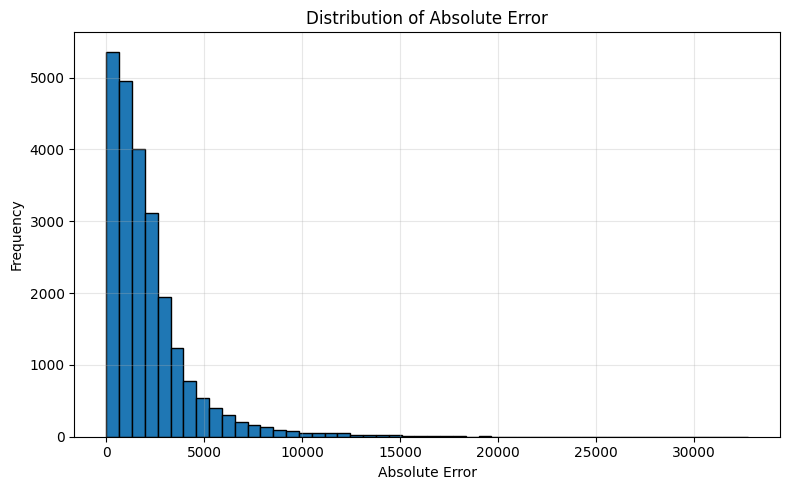

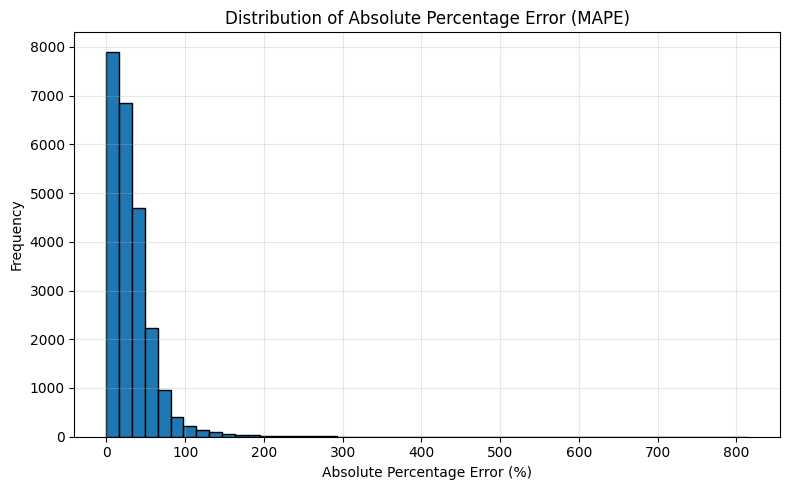

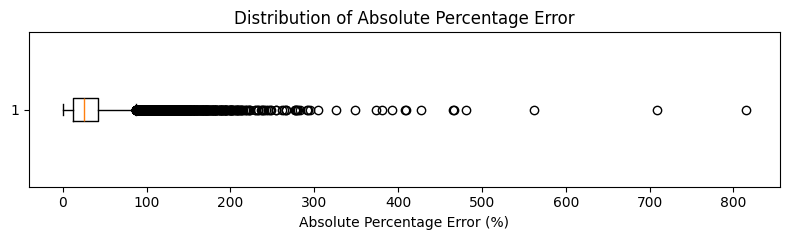

MEAN VS MEDIAN ERROR
Mean Absolute Error : 2132.01
Median Absolute Error : 1546.84
Mean MAPE : 31.22%
Median MAPE : 25.14%


In [9]:
# ==========================================================
# Error Analysis
# ==========================================================
# Analyse the distribution of forecasting errors on the
# validation set.
# ==========================================================

import matplotlib.pyplot as plt

# ==========================================================
# Error Summary Statistics
# ==========================================================

print("=" * 60)
print("ERROR SUMMARY")
print("=" * 60)

print(
    valid_result[
        [
            "abs_error",
            "ape"
        ]
    ].describe()
)

# ==========================================================
# Absolute Error Distribution
# ==========================================================

plt.figure(figsize=(8, 5))

plt.hist(

    valid_result["abs_error"],

    bins=50,

    edgecolor="black"

)

plt.title(
    "Distribution of Absolute Error"
)

plt.xlabel(
    "Absolute Error"
)

plt.ylabel(
    "Frequency"
)

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

# ==========================================================
# Absolute Percentage Error Distribution
# ==========================================================

plt.figure(figsize=(8, 5))

plt.hist(

    valid_result["ape"],

    bins=50,

    edgecolor="black"

)

plt.title(
    "Distribution of Absolute Percentage Error (MAPE)"
)

plt.xlabel(
    "Absolute Percentage Error (%)"
)

plt.ylabel(
    "Frequency"
)

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

# ==========================================================
# Boxplot of Percentage Error
# ==========================================================

plt.figure(figsize=(8, 2.5))

plt.boxplot(

    valid_result["ape"],

    vert=False

)

plt.title(
    "Distribution of Absolute Percentage Error"
)

plt.xlabel(
    "Absolute Percentage Error (%)"
)

plt.tight_layout()

plt.show()

# ==========================================================
# Mean vs Median Error
# ==========================================================

print("=" * 60)
print("MEAN VS MEDIAN ERROR")
print("=" * 60)

print(

    f"Mean Absolute Error : "

    f"{valid_result['abs_error'].mean():.2f}"

)

print(

    f"Median Absolute Error : "

    f"{valid_result['abs_error'].median():.2f}"

)

print(

    f"Mean MAPE : "

    f"{valid_result['ape'].mean():.2f}%"

)

print(

    f"Median MAPE : "

    f"{valid_result['ape'].median():.2f}%"

)

ERROR BY PROMOTION
       Observations          MAE   Median_MAE       MAPE  Median_MAPE
promo                                                                
0             15229  2145.639755  1542.600405  31.368849    25.116271
1              8451  2107.451557  1551.983458  30.958644    25.169022


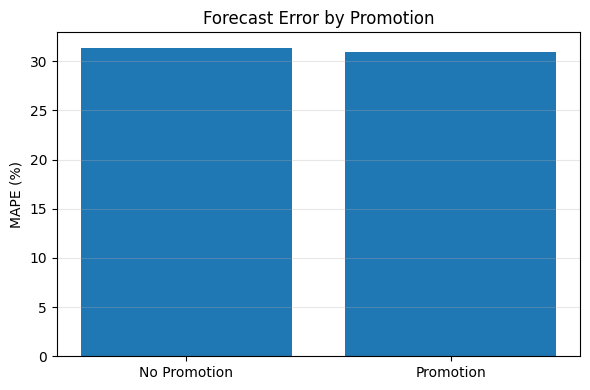

<Figure size 600x500 with 0 Axes>

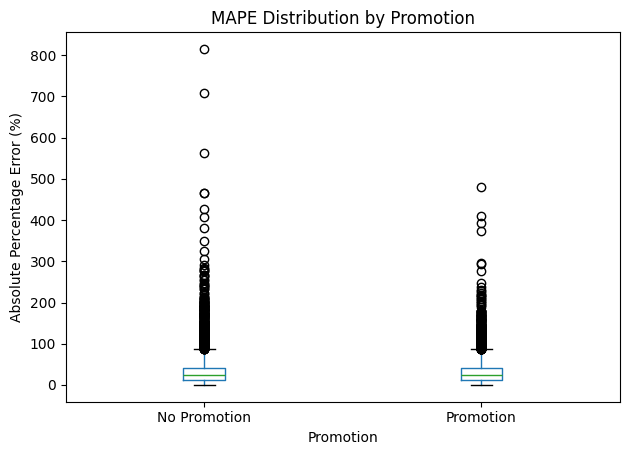

In [10]:
# ==========================================================
# Error Analysis by Promotion
# ==========================================================

promo_error = (

    valid_result

    .groupby("promo")

    .agg(

        Observations=("promo", "count"),

        MAE=("abs_error", "mean"),

        Median_MAE=("abs_error", "median"),

        MAPE=("ape", "mean"),

        Median_MAPE=("ape", "median")

    )

)

print("=" * 60)
print("ERROR BY PROMOTION")
print("=" * 60)

print(promo_error)

plt.figure(figsize=(6, 4))

plt.bar(

    ["No Promotion", "Promotion"],

    promo_error["MAPE"]

)

plt.ylabel("MAPE (%)")

plt.title("Forecast Error by Promotion")

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

plt.show()

plt.figure(figsize=(6, 5))

valid_result.boxplot(

    column="ape",

    by="promo",

    grid=False

)

plt.suptitle("")

plt.title("MAPE Distribution by Promotion")

plt.xlabel("Promotion")

plt.ylabel("Absolute Percentage Error (%)")

plt.xticks([1, 2], ["No Promotion", "Promotion"])

plt.tight_layout()

plt.show()

ERROR BY SALES LEVEL
             Observations    Mean_Sales          MAE       MAPE  Median_MAPE
sales_level                                                                 
Low                  5920   3865.482770  1856.235157  54.728565    45.052104
Medium               5922   5609.148430   719.628261  13.037321    10.477406
High                 5918   7237.927847  1282.536098  17.376913    16.299733
Very High            5920  10979.380236  4669.834732  39.748481    38.725596


C:\Users\setue\AppData\Local\Temp\ipykernel_20160\780559754.py:29: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("sales_level")


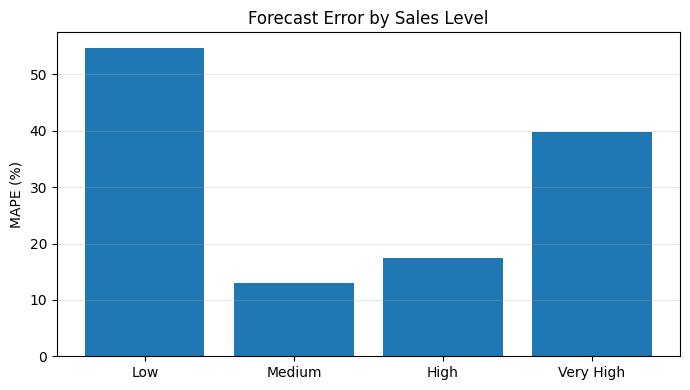

<Figure size 800x500 with 0 Axes>

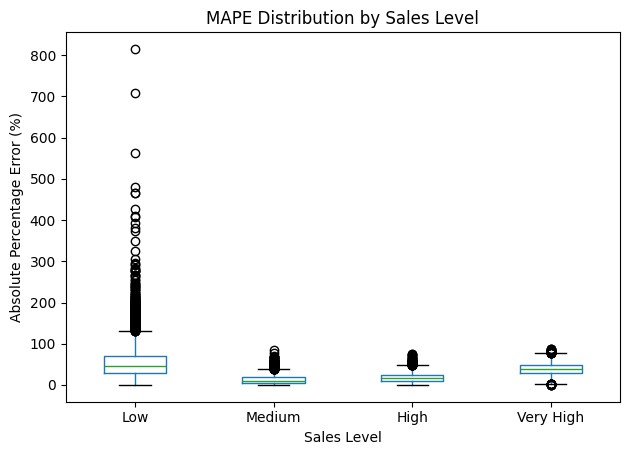

In [11]:
# ==========================================================
# Error Analysis by Sales Level
# ==========================================================

valid_result["sales_level"] = pd.qcut(

    valid_result["sales"],

    q=4,

    labels=[

        "Low",

        "Medium",

        "High",

        "Very High"

    ]

)

sales_error = (

    valid_result

    .groupby("sales_level")

    .agg(

        Observations=("sales","count"),

        Mean_Sales=("sales","mean"),

        MAE=("abs_error","mean"),

        MAPE=("ape","mean"),

        Median_MAPE=("ape","median")

    )

)

print("=" * 60)
print("ERROR BY SALES LEVEL")
print("=" * 60)

print(sales_error)

plt.figure(figsize=(7, 4))

plt.bar(

    sales_error.index,

    sales_error["MAPE"]

)

plt.ylabel("MAPE (%)")

plt.title("Forecast Error by Sales Level")

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

plt.show()

plt.figure(figsize=(8, 5))

valid_result.boxplot(

    column="ape",

    by="sales_level",

    grid=False

)

plt.suptitle("")

plt.title("MAPE Distribution by Sales Level")

plt.xlabel("Sales Level")

plt.ylabel("Absolute Percentage Error (%)")

plt.tight_layout()

plt.show()

TOP 50 LARGEST PREDICTION ERRORS


,store_id,date,sales,prediction,abs_error,ape,promo,school_holiday,open
610749,85,2015-07-05,632,5781.614845,5149.614845,814.812475,0,0,0
582108,666,2015-07-08,591,4779.381508,4188.381508,708.693995,0,0,1
599646,74,2015-06-20,866,5735.753088,4869.753088,562.327146,0,0,1
24928,122,2015-06-30,1156,6711.586205,5555.586205,480.587042,1,1,1
616298,90,2015-07-10,1146,6488.648488,5342.648488,466.199694,0,1,1
600578,75,2015-06-28,1196,6757.320152,5561.320152,464.993324,0,0,0
613494,88,2015-06-08,1276,6733.988967,5457.988967,427.742082,0,0,1
337240,427,2015-06-30,1148,5854.813551,4706.813551,410.001180,1,1,1
600558,75,2015-06-08,1092,5546.223657,4454.223657,407.895939,0,0,1
493396,58,2015-06-30,1281,6317.463073,5036.463073,393.166516,1,1,1


PROMOTION DISTRIBUTION
promo
0    35
1    15
Name: count, dtype: int64
SCHOOL HOLIDAY DISTRIBUTION
school_holiday
0    43
1     7
Name: count, dtype: int64
STORE TYPE DISTRIBUTION
store_type
A    26
D    16
C     6
B     2
Name: count, dtype: int64


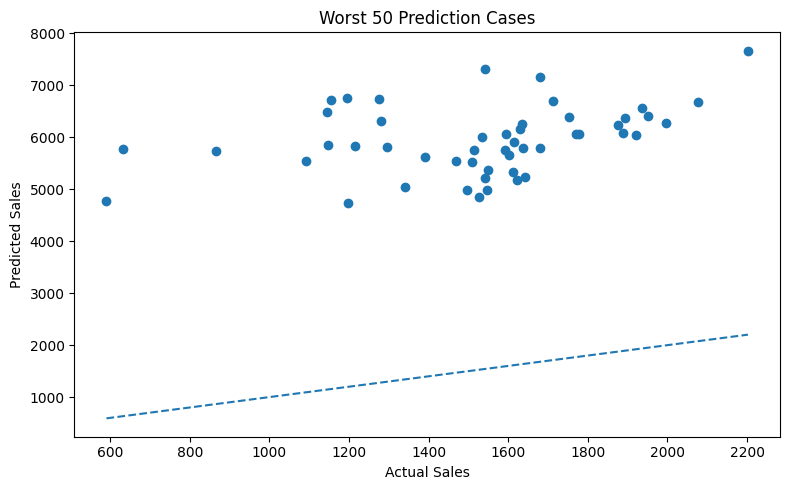

DATE DISTRIBUTION OF WORST 50 CASES
date
2015-06-08    2
2015-06-12    3
2015-06-14    1
2015-06-16    1
2015-06-19    1
2015-06-20    5
2015-06-21    1
2015-06-23    1
2015-06-27    5
2015-06-28    2
2015-06-30    6
2015-07-01    3
2015-07-02    1
2015-07-03    1
2015-07-04    1
2015-07-05    1
2015-07-06    3
2015-07-08    1
2015-07-10    3
2015-07-11    2
2015-07-15    1
2015-07-16    1
2015-07-18    3
2015-07-19    1
Name: count, dtype: int64


In [12]:
# ==========================================================
# Worst Prediction Cases
# ==========================================================

worst_cases = (

    valid_result

    .sort_values(

        "ape",

        ascending=False

    )

    .head(50)

)

print("=" * 60)
print("TOP 50 LARGEST PREDICTION ERRORS")
print("=" * 60)

display(

    worst_cases[

        [

            "store_id",

            "date",

            "sales",

            "prediction",

            "abs_error",

            "ape",

            "promo",

            "school_holiday",

            "open"

        ]

    ]

)
print("=" * 60)
print("PROMOTION DISTRIBUTION")
print("=" * 60)

print(
    worst_cases["promo"]
    .value_counts()
)

print("=" * 60)
print("SCHOOL HOLIDAY DISTRIBUTION")
print("=" * 60)

print(
    worst_cases["school_holiday"]
    .value_counts()
)

####
print("=" * 60)
print("STORE TYPE DISTRIBUTION")
print("=" * 60)

print(
    worst_cases["store_type"]
    .value_counts()
)

plt.figure(figsize=(8,5))

plt.scatter(

    worst_cases["sales"],

    worst_cases["prediction"]

)

plt.plot(

    [

        worst_cases["sales"].min(),

        worst_cases["sales"].max()

    ],

    [

        worst_cases["sales"].min(),

        worst_cases["sales"].max()

    ],

    linestyle="--"

)

plt.xlabel("Actual Sales")

plt.ylabel("Predicted Sales")

plt.title("Worst 50 Prediction Cases")

plt.tight_layout()

plt.show()

print("=" * 60)
print("DATE DISTRIBUTION OF WORST 50 CASES")
print("=" * 60)

print(
    worst_cases["date"]
    .value_counts()
    .sort_index()
)

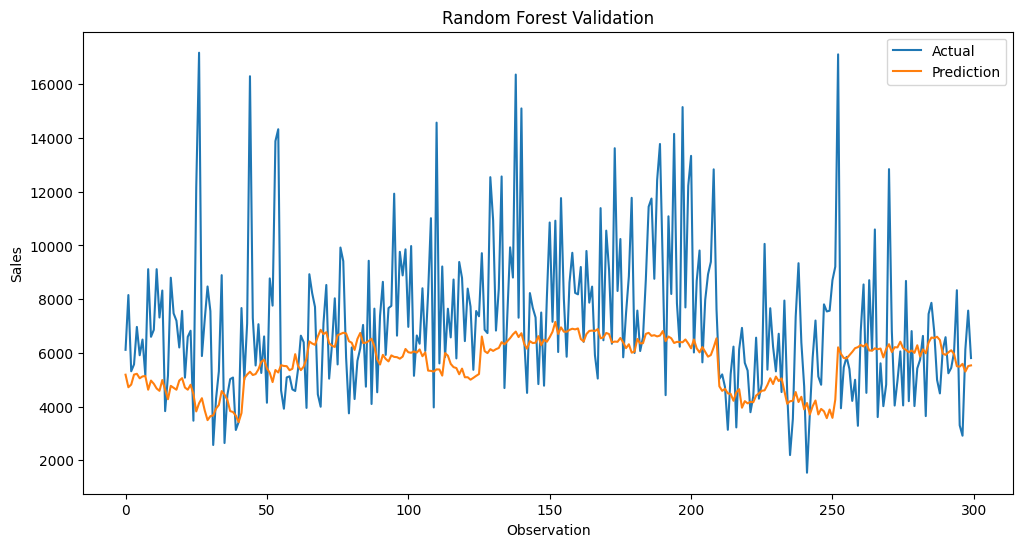

In [13]:
# ==========================================================
# Prediction vs Actual
# ==========================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(
    y_valid.values[:300],
    label="Actual"
)

plt.plot(
    y_pred[:300],
    label="Prediction"
)

plt.legend()

plt.title("Random Forest Validation")

plt.xlabel("Observation")

plt.ylabel("Sales")

plt.show()

FEATURE IMPORTANCE
                 Feature  Importance
0   competition_distance    0.173785
1         rolling_max_28    0.054241
2      rolling_median_28    0.046540
3        rolling_mean_28    0.045721
4         rolling_max_21    0.044384
5         rolling_max_14    0.040317
6         rolling_std_28    0.039396
7      rolling_median_21    0.036418
8      rolling_median_14    0.034806
9        rolling_mean_21    0.032652
10       rolling_mean_14    0.032410
11        rolling_std_14    0.030619
12        rolling_std_21    0.029496
13   customer_prediction    0.027973
14         rolling_max_7    0.026135
15          week_of_year    0.025891
16      rolling_median_7    0.024681
17                  year    0.024062
18         rolling_std_7    0.022472
19        rolling_mean_7    0.021278
20                 month    0.017150
21                lag_28    0.016832
22                 lag_1    0.016392
23                lag_21    0.015991
24                lag_14    0.015943
25                 

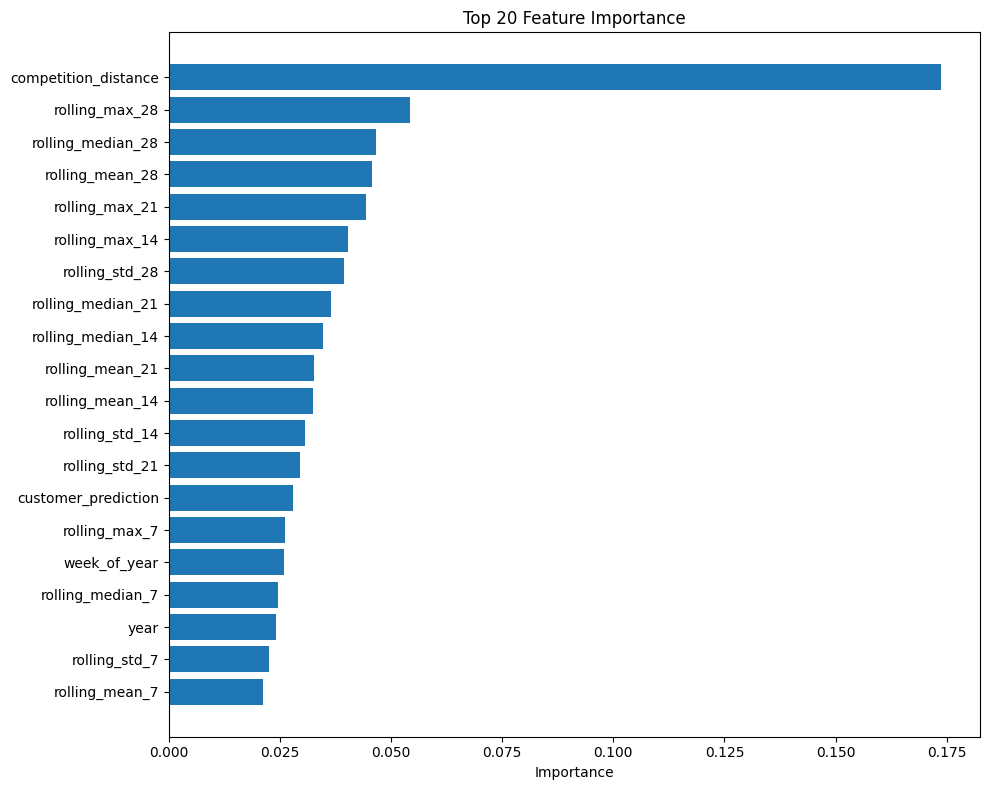

In [14]:
# ==========================================================
# Feature Importance
# ==========================================================

import pandas as pd

feature_importance = pd.DataFrame({

    "Feature": X_train.columns,

    "Importance": rf.feature_importances_

})

feature_importance = (

    feature_importance

    .sort_values(

        by="Importance",

        ascending=False

    )

    .reset_index(drop=True)

)

print("=" * 60)
print("FEATURE IMPORTANCE")
print("=" * 60)

print(feature_importance)

# ==========================================================
# Customer Feature Importance
# ==========================================================

print("\n" + "=" * 60)
print("CUSTOMER PREDICTION FEATURE")
print("=" * 60)

customer_feature = feature_importance[
    feature_importance["Feature"] == "customer_prediction"
    ]

print(customer_feature)

customer_rank = (
        feature_importance.index[
            feature_importance["Feature"] == "customer_prediction"
            ][0] + 1
)

print(f"\nFeature Rank : {customer_rank}")

# ==========================================================
# Plot Top 20 Feature Importance
# ==========================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))

plt.barh(

    feature_importance["Feature"][:20][::-1],

    feature_importance["Importance"][:20][::-1]

)

plt.title(
    "Top 20 Feature Importance"
)

plt.xlabel(
    "Importance"
)

plt.tight_layout()

plt.show()

In [16]:
feature_importance.head(20)

,Feature,Importance
0,competition_distance,0.173785
1,rolling_max_28,0.054241
2,rolling_median_28,0.046540
3,rolling_mean_28,0.045721
4,rolling_max_21,0.044384
5,rolling_max_14,0.040317
6,rolling_std_28,0.039396
7,rolling_median_21,0.036418
8,rolling_median_14,0.034806
9,rolling_mean_21,0.032652


HYPERPARAMETER TUNING WITH ROLLING CV

Evaluating Model 1/4

Evaluating Model 2/4

Evaluating Model 3/4

Evaluating Model 4/4


TUNING RESULTS
   n_estimators max_features  min_samples_leaf       CV_MAE      CV_RMSE  \
0           500         sqrt                10  2649.892814  3545.403430   
1           300         sqrt                10  2651.118775  3546.382051   
2           200         sqrt                10  2651.083998  3545.979464   
3           300         sqrt                 5  2634.713640  3524.816469   

     CV_MAPE  
0  31.398537  
1  31.418142  
2  31.433272  
3  31.477938  

Best Parameters
{'n_estimators': 500, 'max_features': 'sqrt', 'min_samples_leaf': 10}

Best CV MAPE : 31.40%


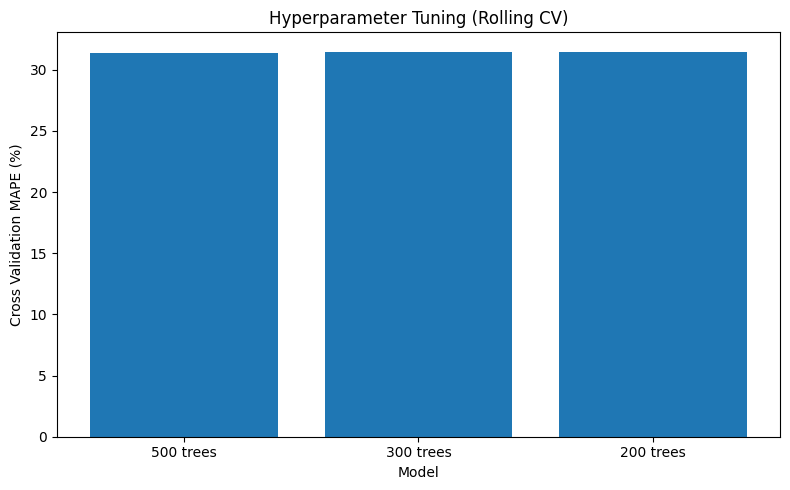

TRAIN FINAL RANDOM FOREST
Final model training completed.
Training observations : 605,696
Number of features    : 58


In [17]:
# ==========================================================
# Hyperparameter Tuning using Rolling Forecast Origin CV
# ==========================================================

print("=" * 60)
print("HYPERPARAMETER TUNING WITH ROLLING CV")
print("=" * 60)

parameter_list = [

    {
        "n_estimators": 200,
        "max_features": "sqrt",
        "min_samples_leaf": 10
    },

    {
        "n_estimators": 300,
        "max_features": "sqrt",
        "min_samples_leaf": 10
    },

    {
        "n_estimators": 500,
        "max_features": "sqrt",
        "min_samples_leaf": 10
    },

    {
        "n_estimators": 300,
        "max_features": "sqrt",
        "min_samples_leaf": 5
    }

]

# Rolling CV settings
n_folds = 3
forecast_horizon = 42

all_dates = np.sort(train_df["date"].unique())

results = []

best_mape = np.inf
best_params = None

for i, params in enumerate(parameter_list, start=1):

    print(f"\nEvaluating Model {i}/{len(parameter_list)}")

    fold_mae = []
    fold_rmse = []
    fold_mape = []

    for fold in range(n_folds):
        valid_end = len(all_dates) - fold * forecast_horizon
        valid_start = valid_end - forecast_horizon

        valid_dates = all_dates[valid_start:valid_end]
        train_dates = all_dates[:valid_start]

        train_fold = train_df[
            train_df["date"].isin(train_dates)
        ].copy()

        valid_fold = train_df[
            train_df["date"].isin(valid_dates)
        ].copy()

        X_tr = train_fold.drop(columns=drop_columns)
        y_tr = train_fold[target]

        X_va = valid_fold.drop(columns=drop_columns)
        y_va = valid_fold[target]

        rf = RandomForestRegressor(

            random_state=42,
            n_jobs=-1,
            **params

        )

        rf.fit(X_tr, y_tr)

        pred = rf.predict(X_va)

        mae = mean_absolute_error(
            y_va,
            pred
        )

        rmse = np.sqrt(
            mean_squared_error(
                y_va,
                pred
            )
        )

        mask = y_va != 0

        mape = (
                np.abs(
                    (
                            y_va[mask] - pred[mask]
                    )
                    /
                    y_va[mask]
                ).mean()
                * 100
        )

        fold_mae.append(mae)
        fold_rmse.append(rmse)
        fold_mape.append(mape)

    avg_mae = np.mean(fold_mae)
    avg_rmse = np.mean(fold_rmse)
    avg_mape = np.mean(fold_mape)

    results.append({

        "n_estimators": params["n_estimators"],
        "max_features": params["max_features"],
        "min_samples_leaf": params["min_samples_leaf"],
        "CV_MAE": avg_mae,
        "CV_RMSE": avg_rmse,
        "CV_MAPE": avg_mape

    })

    if avg_mape < best_mape:
        best_mape = avg_mape
        best_params = params

results = (
    pd.DataFrame(results)
    .sort_values("CV_MAPE")
    .reset_index(drop=True)
)

print("\n")
print("=" * 60)
print("TUNING RESULTS")
print("=" * 60)

print(results)

print("\nBest Parameters")
print(best_params)

print(f"\nBest CV MAPE : {best_mape:.2f}%")

plt.figure(figsize=(8, 5))

labels = (
        results["n_estimators"].astype(str)
        + " trees"
)

plt.bar(
    labels,
    results["CV_MAPE"]
)

plt.title("Hyperparameter Tuning (Rolling CV)")

plt.xlabel("Model")

plt.ylabel("Cross Validation MAPE (%)")

plt.tight_layout()

plt.show()

# ==========================================================
# Train Final Random Forest on Full Historical Data
# ==========================================================

print("=" * 60)
print("TRAIN FINAL RANDOM FOREST")
print("=" * 60)

# Use all available historical data
full_df = sales_fe.dropna().copy()

X_full = full_df.drop(columns=drop_columns)
y_full = full_df[target]

# Train final model
final_rf = RandomForestRegressor(
    **best_params,
    random_state=42,
    n_jobs=-1
)

final_rf.fit(X_full, y_full)

print("Final model training completed.")

print(f"Training observations : {len(full_df):,}")
print(f"Number of features    : {X_full.shape[1]}")

PERMUTATION FEATURE IMPORTANCE
                 Feature  Importance
0   competition_distance  565.267233
1         rolling_max_28  326.242099
2      rolling_median_28  286.492211
3        rolling_mean_28  279.934107
4         rolling_max_21  268.471776
5         rolling_max_14  243.034900
6           store_type_d  218.824743
7      rolling_median_21  208.943785
8      rolling_median_14  199.433563
9         rolling_std_28  198.652635
10          store_type_a  196.732089
11          assortment_a  191.871774
12       rolling_mean_21  190.557818
13       rolling_mean_14  186.255917
14          assortment_c  169.489579
15        rolling_std_14  149.791760
16   customer_prediction  147.062269
17        rolling_std_21  141.114081
18         rolling_max_7  110.571954
19      rolling_median_7   99.971837

CUSTOMER PREDICTION FEATURE
                Feature  Importance
16  customer_prediction  147.062269

Permutation Rank : 17


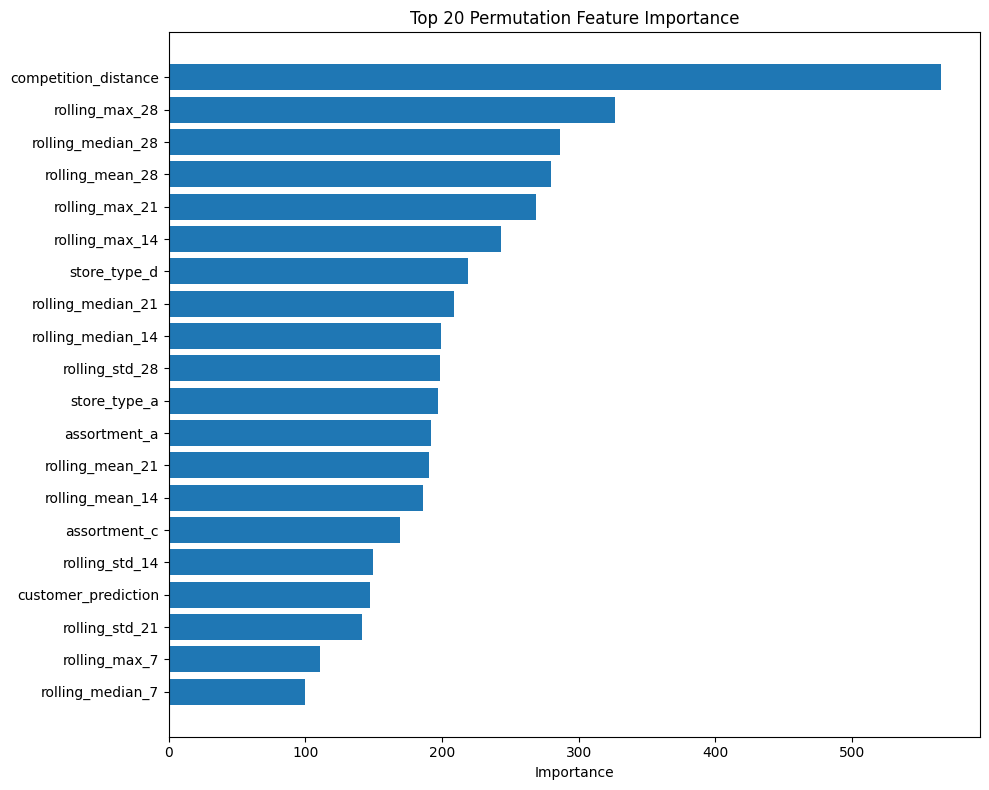

In [26]:
from sklearn.inspection import permutation_importance

# ==========================================================
# Permutation Feature Importance
# ==========================================================

perm_importance = permutation_importance(

    final_rf,

    X_valid,

    y_valid,

    n_repeats=3,

    random_state=42,

    scoring="neg_mean_absolute_error",

    n_jobs=1

)

perm_df = pd.DataFrame({

    "Feature": X_valid.columns,

    "Importance": perm_importance.importances_mean

})

perm_df = (

    perm_df

    .sort_values(

        by="Importance",

        ascending=False

    )

    .reset_index(drop=True)

)

print("=" * 60)
print("PERMUTATION FEATURE IMPORTANCE")
print("=" * 60)

print(perm_df.head(20))

# ==========================================================
# Customer Prediction Importance
# ==========================================================

print("\n" + "=" * 60)
print("CUSTOMER PREDICTION FEATURE")
print("=" * 60)

customer_perm = perm_df[
    perm_df["Feature"] == "customer_prediction"
    ]

print(customer_perm)

customer_rank = (

        perm_df.index[
            perm_df["Feature"] == "customer_prediction"
            ][0]

        + 1

)

print(f"\nPermutation Rank : {customer_rank}")

# ==========================================================
# Plot
# ==========================================================

plt.figure(figsize=(10, 8))

plt.barh(

    perm_df["Feature"][:20][::-1],

    perm_df["Importance"][:20][::-1]

)

plt.title(
    "Top 20 Permutation Feature Importance"
)

plt.xlabel(
    "Importance"
)

plt.tight_layout()

plt.show()

In [24]:
# ==========================================================
# Prepare Future Features
# ==========================================================
future_drop_columns = [
    "date",
    "store_id"
]

future_X = future_fe.drop(
    columns=future_drop_columns
)

future_X = future_X[X_full.columns]

# ==========================================================
# Align Feature Order
# ==========================================================

future_X = future_X[X_full.columns]

print("=" * 60)
print("CHECK FUTURE FEATURES")
print("=" * 60)

print("Training shape :", X_full.shape)
print("Future shape   :", future_X.shape)

print("\nFeature names identical:")
print(X_full.columns.equals(future_X.columns))

print("\nCustomer Feature Included:")
print("customer_prediction" in future_X.columns)

# ==========================================================
# Predict Future Sales
# ==========================================================

future_pred = final_rf.predict(future_X)

future_result = future_fe.copy()

future_result["sales_prediction"] = future_pred

print("=" * 60)
print("FUTURE PREDICTION")
print("=" * 60)

print(
    future_result[
        [
            "store_id",
            "date",
            "customer_prediction",
            "sales_prediction"
        ]
    ].head()
)

print("\nPrediction Summary")

print(
    future_result["sales_prediction"].describe()
)

# ==========================================================
# Save Prediction
# ==========================================================

future_result.to_csv(
    processed_dir / "future_prediction_rf_customer.csv",
    index=False
)

print("Prediction file saved successfully.")

CHECK FUTURE FEATURES
Training shape : (605696, 58)
Future shape   : (40560, 58)

Feature names identical:
True

Customer Feature Included:
True
FUTURE PREDICTION
   store_id       date  customer_prediction  sales_prediction
0         1 2015-09-17           437.370690       4343.569497
1         2 2015-09-17           667.137207       6877.261924
2         3 2015-09-17           673.250164       6427.436607
3         4 2015-09-17           752.277034       6745.211897
4         5 2015-09-17           676.591182       6702.193885

Prediction Summary
count    40560.000000
mean      5786.704609
std       1169.189302
min       1453.822282
25%       5241.140247
50%       5903.268039
75%       6493.673165
max      10317.501659
Name: sales_prediction, dtype: float64
Prediction file saved successfully.


In [25]:
# ==========================================================
# Weekly Aggregation
# ==========================================================

future_result = future_result.sort_values(
    ["date", "store_id"]
).reset_index(drop=True)

forecast_start = future_result["date"].min()

future_result["forecast_week"] = (

                                         (future_result["date"] - forecast_start).dt.days // 7

                                 ) + 1

print("=" * 60)
print("FORECAST WEEKS")
print("=" * 60)

print(
    future_result["forecast_week"]
    .value_counts()
    .sort_index()
)

# ==========================================================
# Weekly Forecast by Store
# ==========================================================

store_weekly = (

    future_result

    .groupby(

        ["store_id", "forecast_week"],

        as_index=False

    )["sales_prediction"]

    .sum()

)

print("=" * 60)
print("STORE WEEKLY FORECAST")
print("=" * 60)

print(store_weekly.head())

store_weekly.to_csv(

    processed_dir /

    "store_weekly_forecast_customer.csv",

    index=False

)

# ==========================================================
# Recover Store Type
# ==========================================================

future_result["store_type"] = np.select(

    [

        future_result["store_type_a"] == 1,

        future_result["store_type_b"] == 1,

        future_result["store_type_c"] == 1,

        future_result["store_type_d"] == 1

    ],

    [

        "A",

        "B",

        "C",

        "D"

    ]

)

# ==========================================================
# Weekly Forecast by Store Type
# ==========================================================

storetype_weekly = (

    future_result

    .groupby(

        ["store_type", "forecast_week"],

        as_index=False

    )["sales_prediction"]

    .sum()

)

print(storetype_weekly)

storetype_weekly.to_csv(

    processed_dir /

    "storetype_weekly_forecast_customer.csv",

    index=False

)

# ==========================================================
# Weekly Forecast for Company
# ==========================================================

company_weekly = (

    future_result

    .groupby(

        "forecast_week",

        as_index=False

    )["sales_prediction"]

    .sum()

)

print(company_weekly)

company_weekly.to_csv(

    processed_dir /

    "company_weekly_forecast_customer.csv",

    index=False

)

# ==========================================================
# Total Forecast over Next 6 Weeks
# ==========================================================

total_sales = future_result["sales_prediction"].sum()

print("=" * 60)
print("TOTAL SALES OVER NEXT 6 WEEKS")
print("=" * 60)

print(f"{total_sales:,.2f}")

# ==========================================================
# Check Customer Feature
# ==========================================================

print("=" * 60)
print("CUSTOMER FEATURE USED")
print("=" * 60)

print(

    future_result[
        [
            "store_id",
            "date",
            "customer_prediction",
            "sales_prediction"
        ]
    ].head()

)

FORECAST WEEKS
forecast_week
1    4732
2    4732
3    4732
4    4732
5    4732
6    4732
7    4732
8    4732
9    2704
Name: count, dtype: int64
STORE WEEKLY FORECAST
   store_id  forecast_week  sales_prediction
0         1              1      30246.860667
1         1              2      29050.257064
2         1              3      29379.445827
3         1              4      30096.316347
4         1              5      29724.647470
   store_type  forecast_week  sales_prediction
0           A              1      1.521610e+07
1           A              2      1.524899e+07
2           A              3      1.523718e+07
3           A              4      1.523123e+07
4           A              5      1.524499e+07
5           A              6      1.525439e+07
6           A              7      1.527969e+07
7           A              8      1.525130e+07
8           A              9      8.714860e+06
9           B              1      3.891671e+05
10          B              2      3.922956e+05